In [36]:
!pip install ema_workbench

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.7/28.7 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.4/124.4 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 51.5 MB/s eta 0:00:00


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print(np.__version__)
print(np.__file__)
print(hasattr(np, "bool"))

data = pd.read_excel(
    "SCI_2025_reshaped_rows_africaR5.xlsx",
    sheet_name="Data"
)

# Remove units row
data = data.iloc[1:].reset_index(drop=True)

# Convert all columns except Model and Scenario
for col in data.columns[2:]:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Remove rows with missing values
data = data.dropna()

print(data.shape)
print(data.dtypes)

2.0.2
/usr/local/lib/python3.12/dist-packages/numpy/__init__.py
True
(763, 15)
Model                      object
Scenario                   object
Emissions|CO2             float64
Final Energy              float64
Primary Energy            float64
Primary Energy|Coal       float64
Primary Energy|Oil        float64
Primary Energy|Gas        float64
Primary Energy|Biomass    float64
Primary Energy|Nuclear    float64
Primary Energy|Solar      float64
Primary Energy|Wind       float64
Population                float64
Consumption               float64
GDP|PPP                   float64
dtype: object


In [7]:
data

,Model,Scenario,Emissions|CO2,Final Energy,Primary Energy,Primary Energy|Coal,Primary Energy|Oil,Primary Energy|Gas,Primary Energy|Biomass,Primary Energy|Nuclear,Primary Energy|Solar,Primary Energy|Wind,Population,Consumption,GDP|PPP
30,AIM/CGE 2.1,COMMIT-Bridge,484.243300,69.482400,127.308300,1.081000,39.868000,44.274500,35.568100,0.745400,0.935100,0.730400,2866.048100,18203.687391,62793.363430
31,AIM/CGE 2.1,COMMIT-Current-Policies,10104.355300,115.300100,170.443400,31.303600,51.716200,54.504300,29.380200,0.310100,0.318000,0.347600,2866.048100,20902.432877,68955.882426
42,AIM/CGE V2.2,ENGAGE-INDCi2030-1000f,-640.066400,82.514300,113.481400,1.662000,17.018300,9.646200,31.683500,0.733600,27.099900,22.068600,3066.028300,82819.194300,228581.114300
43,AIM/CGE V2.2,ENGAGE-INDCi2030-1200,20.002100,83.374500,113.527700,2.009600,20.427900,11.789800,28.053400,0.722700,25.846500,21.238200,3066.028300,83544.557100,229555.901800
44,AIM/CGE V2.2,ENGAGE-INDCi2030-1200f,-568.917800,82.155600,115.446700,2.439400,17.411500,11.881500,31.320700,0.732300,26.514300,21.560700,3066.028300,82816.205600,228435.399300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1533,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1000,-1213.658872,69.817854,164.017452,0.370591,31.527821,34.341346,45.495861,0.007509,20.211347,29.819351,2989.281279,51673.228959,149206.505492
1534,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1600,818.406813,84.216179,193.325452,1.001367,55.873002,43.458749,45.495287,0.005344,18.890172,26.362235,2989.281279,54492.625563,157603.483348
1535,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_400,-2545.867781,59.732099,137.755241,0.187609,15.753675,21.340087,45.495861,0.014737,21.044236,31.660949,2989.281279,47886.483860,137933.591295
1536,WITCH-GLOBIOM 4.4,CD-LINKS-NPi,14813.945615,110.815609,266.727624,16.984765,119.002030,89.249980,17.162595,0.003245,8.421035,13.668876,2989.281279,59699.530349,169939.100302


In [27]:
data["Consumption_per_capita"] = (
    data["Consumption"] / data["Population"]
)

data["Final_Energy_per_capita"] = (
    data["Final Energy"] / data["Population"]
)

# Check
print(data[[
    "Consumption",
    "Final Energy",
    "Population",
    "Consumption_per_capita",
    "Final_Energy_per_capita"
]].head())

     Consumption  Final Energy  Population  Consumption_per_capita  \
30  18203.687391       69.4824   2866.0481                6.351494   
31  20902.432877      115.3001   2866.0481                7.293120   
42  82819.194300       82.5143   3066.0283               27.011882   
43  83544.557100       83.3745   3066.0283               27.248462   
44  82816.205600       82.1556   3066.0283               27.010907   

    Final_Energy_per_capita  
30                 0.024243  
31                 0.040230  
42                 0.026912  
43                 0.027193  
44                 0.026795  


In [28]:
data

,Model,Scenario,Emissions|CO2,Final Energy,Primary Energy,Primary Energy|Coal,Primary Energy|Oil,Primary Energy|Gas,Primary Energy|Biomass,Primary Energy|Nuclear,Primary Energy|Solar,Primary Energy|Wind,Population,Consumption,GDP|PPP,Consumption_per_capita,Final_Energy_per_capita
30,AIM/CGE 2.1,COMMIT-Bridge,484.243300,69.482400,127.308300,1.081000,39.868000,44.274500,35.568100,0.745400,0.935100,0.730400,2866.048100,18203.687391,62793.363430,6.351494,0.024243
31,AIM/CGE 2.1,COMMIT-Current-Policies,10104.355300,115.300100,170.443400,31.303600,51.716200,54.504300,29.380200,0.310100,0.318000,0.347600,2866.048100,20902.432877,68955.882426,7.293120,0.040230
42,AIM/CGE V2.2,ENGAGE-INDCi2030-1000f,-640.066400,82.514300,113.481400,1.662000,17.018300,9.646200,31.683500,0.733600,27.099900,22.068600,3066.028300,82819.194300,228581.114300,27.011882,0.026912
43,AIM/CGE V2.2,ENGAGE-INDCi2030-1200,20.002100,83.374500,113.527700,2.009600,20.427900,11.789800,28.053400,0.722700,25.846500,21.238200,3066.028300,83544.557100,229555.901800,27.248462,0.027193
44,AIM/CGE V2.2,ENGAGE-INDCi2030-1200f,-568.917800,82.155600,115.446700,2.439400,17.411500,11.881500,31.320700,0.732300,26.514300,21.560700,3066.028300,82816.205600,228435.399300,27.010907,0.026795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1533,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1000,-1213.658872,69.817854,164.017452,0.370591,31.527821,34.341346,45.495861,0.007509,20.211347,29.819351,2989.281279,51673.228959,149206.505492,17.286172,0.023356
1534,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1600,818.406813,84.216179,193.325452,1.001367,55.873002,43.458749,45.495287,0.005344,18.890172,26.362235,2989.281279,54492.625563,157603.483348,18.229340,0.028173
1535,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_400,-2545.867781,59.732099,137.755241,0.187609,15.753675,21.340087,45.495861,0.014737,21.044236,31.660949,2989.281279,47886.483860,137933.591295,16.019397,0.019982
1536,WITCH-GLOBIOM 4.4,CD-LINKS-NPi,14813.945615,110.815609,266.727624,16.984765,119.002030,89.249980,17.162595,0.003245,8.421035,13.668876,2989.281279,59699.530349,169939.100302,19.971199,0.037071


In [29]:
data.describe()

,Emissions|CO2,Final Energy,Primary Energy,Primary Energy|Coal,Primary Energy|Oil,Primary Energy|Gas,Primary Energy|Biomass,Primary Energy|Nuclear,Primary Energy|Solar,Primary Energy|Wind,Population,Consumption,GDP|PPP,Consumption_per_capita,Final_Energy_per_capita
count,763.000000,763.000000,763.000000,7.630000e+02,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000
mean,2808.354541,165.914104,233.530035,1.131130e+01,24.547184,40.234814,27.297251,4.988129,77.587636,42.515590,3066.107376,74343.860493,168041.884395,24.501126,0.054486
std,5611.524906,54.092721,62.749938,2.797913e+01,23.798001,26.348405,14.003067,8.839187,45.660630,23.221205,348.988732,37929.915797,35964.954178,12.419057,0.018395
min,-5709.398217,51.653223,59.197167,-3.469447e-18,0.000000,0.000003,0.018858,0.000000,0.318000,0.347600,2098.103000,0.000000,43362.155674,0.000000,0.013864
25%,-413.785220,111.851824,192.216818,4.575000e-02,8.005010,17.084108,17.988200,0.000000,30.989675,25.633154,3060.261200,43672.678800,155948.524735,14.306533,0.037964
50%,909.474452,176.465932,237.257728,9.118010e-01,17.662100,40.693745,26.439547,0.224714,84.123400,39.452108,3087.570000,70759.721939,161725.479000,22.438951,0.056860
75%,3778.480000,211.725410,276.171646,5.981336e+00,35.028680,57.376256,38.093220,5.625638,112.790229,55.318644,3176.039094,103931.159239,184198.853003,33.659140,0.069105
max,33286.834068,294.773164,434.727700,1.893463e+02,132.516287,168.979412,70.450764,50.719059,265.973856,113.478943,4619.555000,137187.352048,330977.384838,56.504341,0.136756


In [90]:
outcome_interest = 2
factors = list(range(5,13)) + [ 14]
#factors = [6, 7, 8, 9]

In [91]:
factors

[5, 6, 7, 8, 9, 10, 11, 12, 14]

In [92]:
print(data.shape)

(763, 18)


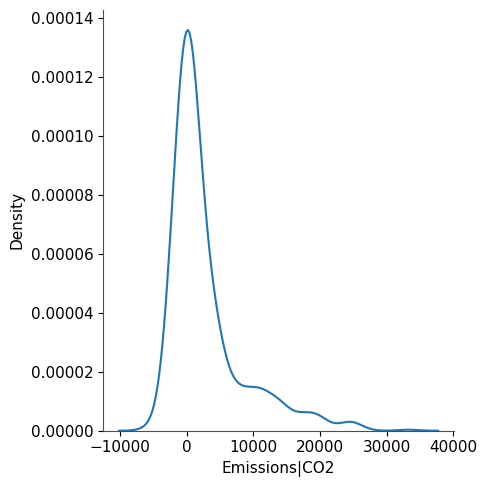

In [93]:

import seaborn as sns
sns.displot(data.iloc[:, outcome_interest],kind='kde')

In [94]:
#define threshold for outcome of interest

threshold_interest = 0

x = data.iloc[:, factors]
y = data.iloc[:, outcome_interest].values < threshold_interest

print(f"There are {sum(y)} cases of interest, out of {len(y)} scenarios")

There are 266 cases of interest, out of 763 scenarios


In [95]:
# from ema_workbench.analysis import cart

# cart_alg = cart.CART(x, y)
# cart_alg.build_tree()

# fig = cart_alg.show_tree()
# fig.set_size_inches((18, 12))
# plt.show()

In [96]:
#PRIM analysis
from ema_workbench.analysis import prim
from ema_workbench.util import ema_logging

#ema_logging.log_to_stderr(ema_logging.INFO);

In [97]:
prim_alg = prim.Prim(x, y)
box1 = prim_alg.find_box()

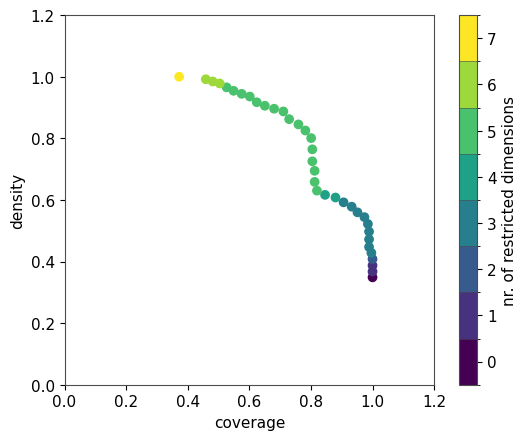

In [98]:
#Visualize first box tradeoff
box1.show_tradeoff()
plt.show()

In [99]:
box1.inspect_tradeoff()

alt.VConcatChart(...)

In [100]:
box1.inspect(style='data')

[(coverage     0.372180
  density      1.000000
  id          35.000000
  k           99.000000
  mass         0.129751
  mean         1.000000
  n           99.000000
  res_dim      7.000000
  Name: 35, dtype: float64,
                                box 35                                     
                                   min          max  qp value      qp value
  Primary Energy|Coal    -3.469447e-18     6.845567       NaN  1.000000e+00
  Primary Energy|Oil      0.000000e+00    15.649237       NaN  5.594661e-07
  Primary Energy|Gas      4.029750e+00    31.176692  0.377050  2.665086e-07
  Primary Energy|Biomass  2.364140e+01    70.450764  1.000000           NaN
  Primary Energy|Nuclear  3.500000e-04    50.719059  0.445674           NaN
  Primary Energy|Solar    3.180000e-01   159.396671       NaN  1.000000e+00
  Population              2.098103e+03  3306.216025       NaN  9.573644e-03)]

In [102]:
#emissions_thr = data["Emissions|CO2"].median()
energy_thr = data["Final_Energy_per_capita"].median()
emissions_thr = 0
print(emissions_thr)
print(energy_thr)

0
0.05685958920497069


In [103]:
def classify(row):

    if row["Emissions|CO2"] <= emissions_thr:
        if row["Final_Energy_per_capita"] >= energy_thr:
            return "Sustainable Development"

        else:
            return "Low Carbon, Energy Poverty"

    else:
        if row["Final_Energy_per_capita"] >= energy_thr:
            return "Carbon Intensive Growth"

        else:
            return "High Carbon, Energy Poverty"

data["quadrant"] = data.apply(classify, axis=1)

In [104]:
data["quadrant"].value_counts()

,count
quadrant,
Carbon Intensive Growth,264
"High Carbon, Energy Poverty",228
"Low Carbon, Energy Poverty",153
Sustainable Development,118


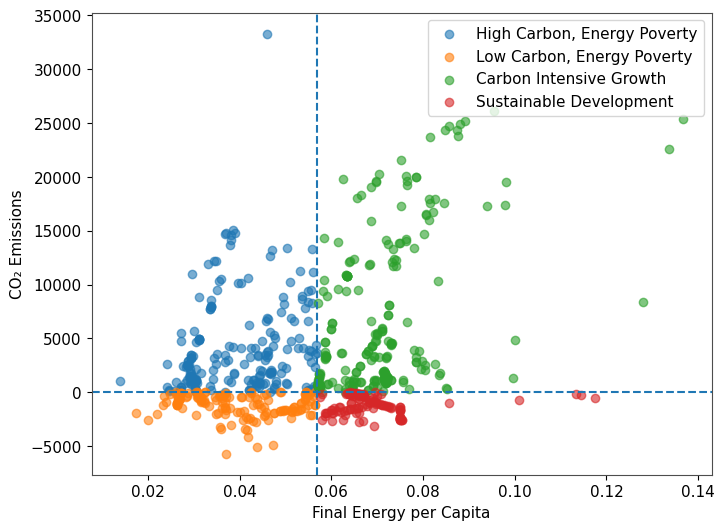

In [105]:
plt.figure(figsize=(8,6))

for q in data["quadrant"].unique():

    subset = data[data["quadrant"] == q]

    plt.scatter(
        subset["Final_Energy_per_capita"],
        subset["Emissions|CO2"],
        alpha=0.6,
        label=q
    )

plt.axhline(emissions_thr, ls="--")
plt.axvline(energy_thr, ls="--")

plt.xlabel("Final Energy per Capita")
plt.ylabel("CO₂ Emissions")
plt.legend()
plt.show()

In [106]:
y_sd = (
    data["quadrant"] == "Sustainable Development"
).astype(int)

prim_sd = prim.Prim(x, y_sd.values)
box_sd = prim_sd.find_box()

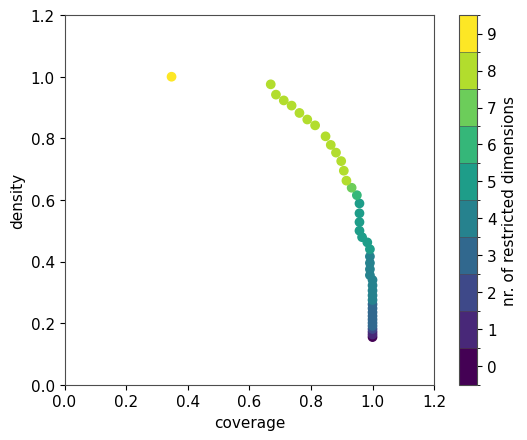

In [107]:
box_sd.show_tradeoff()
plt.show()

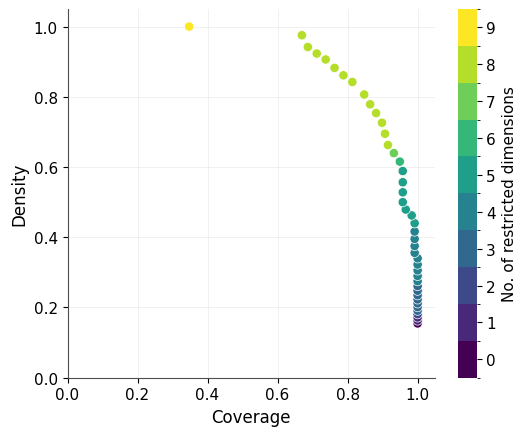

In [108]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

traj = box_sd.peeling_trajectory

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "0.3",
    "xtick.direction": "out",
    "ytick.direction": "out",
})

fig, ax = plt.subplots(figsize=(5.5, 4.5))

n_levels = int(traj["res_dim"].max()) + 1
cmap = plt.get_cmap("viridis", n_levels)
norm = mpl.colors.BoundaryNorm(np.arange(-0.5, n_levels + 0.5, 1), n_levels)

sc = ax.scatter(
    traj["coverage"], traj["density"],
    c=traj["res_dim"], cmap=cmap, norm=norm,
    s=45, edgecolor="white", linewidth=0.5, zorder=3,
)

ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Coverage", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.25, linewidth=0.5)

cbar = fig.colorbar(sc, ax=ax, ticks=range(n_levels))
cbar.set_label("No. of restricted dimensions", fontsize=11)
cbar.outline.set_visible(False)

plt.tight_layout()
plt.savefig("box_sd_tradeoff.png", dpi=600, bbox_inches="tight")
plt.savefig("box_sd_tradeoff.pdf", bbox_inches="tight")  # vector, for LaTeX
plt.show()

In [122]:
box_sd.inspect(style='data')

[(coverage     0.347458
  density      1.000000
  id          42.000000
  k           41.000000
  mass         0.053735
  mean         1.000000
  n           41.000000
  res_dim      9.000000
  Name: 42, dtype: float64,
                                box 42                                       
                                   min            max  qp value      qp value
  Primary Energy|Coal    -3.469447e-18       0.073750       NaN  4.061084e-01
  Primary Energy|Oil      0.000000e+00      20.937450       NaN  1.000000e+00
  Primary Energy|Gas      6.280300e+00      31.536461  1.000000  3.791831e-11
  Primary Energy|Biomass  1.885780e-02      52.099859       NaN  1.000000e+00
  Primary Energy|Nuclear  2.500000e-04      50.719059  0.358777           NaN
  Primary Energy|Solar    8.370233e+01     265.973856  1.000000           NaN
  Primary Energy|Wind     4.080441e+01     113.478943  0.381078           NaN
  Population              2.098103e+03    3287.048043       NaN  1.000000e+00


[<Figure size 640x480 with 1 Axes>]

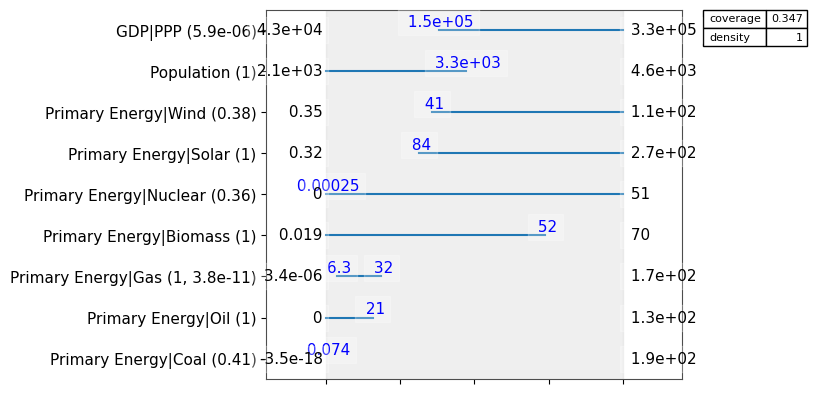

In [123]:
box_sd.inspect(style='graph')

In [124]:
box_sd.inspect_tradeoff()

alt.VConcatChart(...)

coverage      0.813559
density       0.842105
id           35.000000
k            96.000000
mass          0.149410
mean          0.842105
n           114.000000
res_dim       8.000000
Name: 35, dtype: float64

                              box 35                                   
                                 min            max  qp value  qp value
Primary Energy|Coal    -3.469447e-18      36.910860       NaN  0.562475
Primary Energy|Oil      0.000000e+00      20.937450       NaN  0.000338
Primary Energy|Gas      3.579820e-01      43.958422  0.202997  0.000001
Primary Energy|Biomass  1.885780e-02      52.099859       NaN  0.493997
Primary Energy|Solar    4.875820e+01     265.973856  0.001883       NaN
Primary Energy|Wind     4.080441e+01     113.478943  0.003684       NaN
Population              2.098103e+03    3287.048043       NaN  0.019424
GDP|PPP                 1.526521e+05  330977.384838  0.000006       NaN



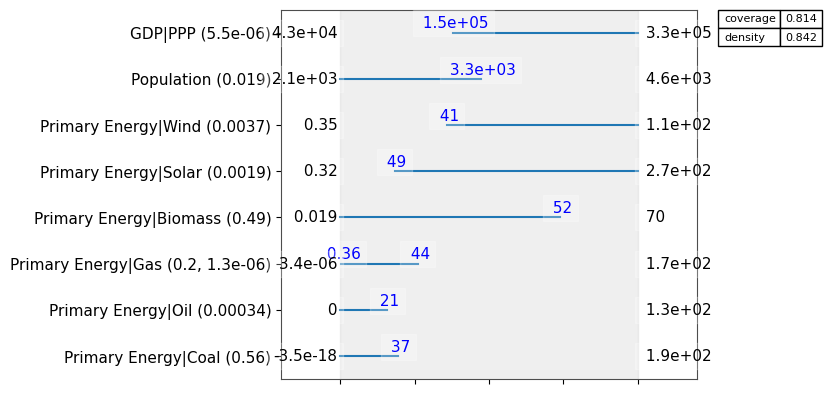

In [125]:
selected_box=35
box_sd.inspect(selected_box)
box_sd.inspect(selected_box, style="graph")
plt.show()

In [126]:
y_hcp = (
    data["quadrant"] == "High Carbon, Energy Poverty"
).astype(int)

prim_hcp = prim.Prim(x, y_hcp.values)
box_hcp = prim_hcp.find_box()

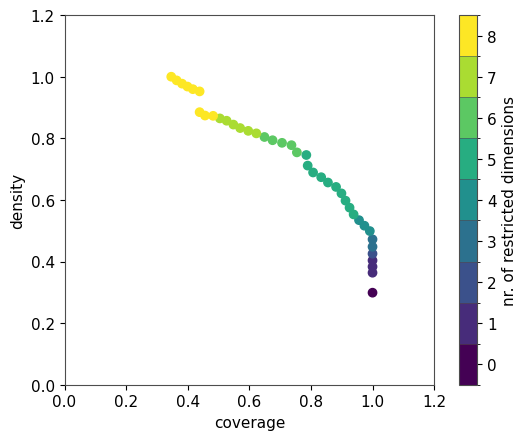

In [127]:
box_hcp.show_tradeoff()
plt.show()

In [128]:
box_hcp.inspect(style='data')

[(coverage     0.346491
  density      1.000000
  id          39.000000
  k           79.000000
  mass         0.103539
  mean         1.000000
  n           79.000000
  res_dim      8.000000
  Name: 39, dtype: float64,
                                box 39                                       
                                   min            max  qp value      qp value
  Primary Energy|Coal         0.706478      16.897064  0.072874  1.716331e-10
  Primary Energy|Oil         16.347875      87.373448  0.000322  1.250306e-04
  Primary Energy|Gas         15.385803     168.979412  0.000153           NaN
  Primary Energy|Biomass      0.018858      48.244810       NaN  3.969333e-01
  Primary Energy|Nuclear      0.000000       0.738600       NaN  7.077194e-02
  Primary Energy|Solar        0.318000      81.632380       NaN  8.809248e-03
  Primary Energy|Wind         0.347600      45.795093       NaN  5.370044e-04
  GDP|PPP                 43362.155674  229435.687450       NaN  1.000000e+00)

[<Figure size 640x480 with 1 Axes>]

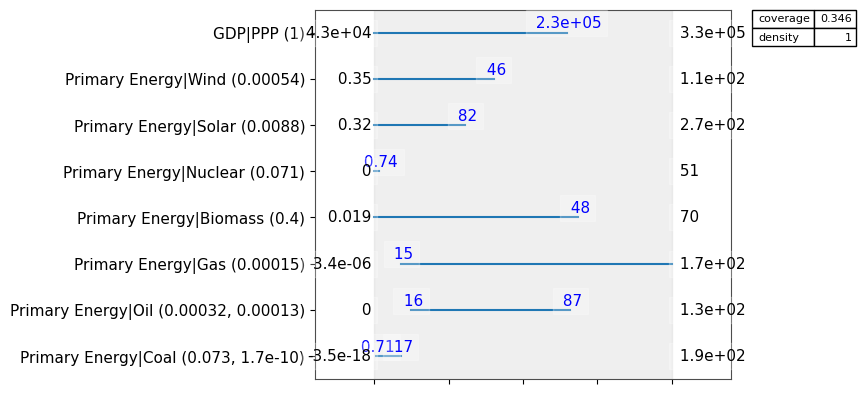

In [132]:
box_hcp.inspect(style='graph')

In [130]:
box_hcp.inspect_tradeoff()

alt.VConcatChart(...)

coverage      0.649123
density       0.804348
id           24.000000
k           148.000000
mass          0.241153
mean          0.804348
n           184.000000
res_dim       6.000000
Name: 24, dtype: float64

                           box 24                                
                              min         max  qp value  qp value
Primary Energy|Coal      0.022850   38.714187  0.544432  0.000080
Primary Energy|Oil      12.173388  132.516287  0.103688       NaN
Primary Energy|Gas      15.385803  168.979412  0.057973       NaN
Primary Energy|Nuclear   0.000000    4.985690       NaN  0.403155
Primary Energy|Solar     0.318000   92.054121       NaN  0.006661
Primary Energy|Wind      0.347600   48.575719       NaN  0.000022



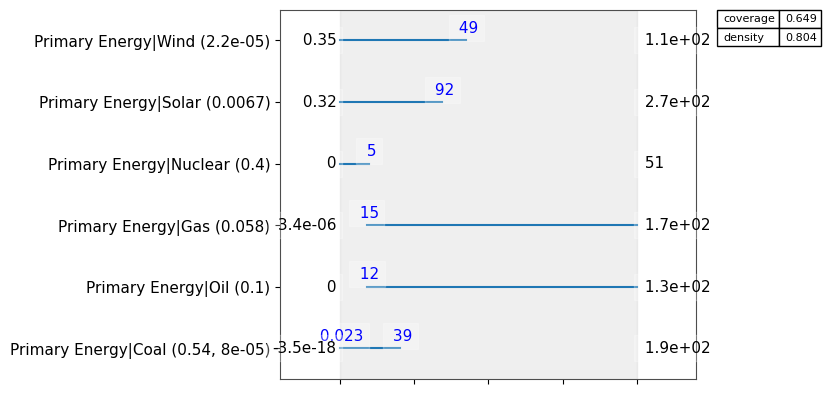

In [131]:
selected_box=24
box_hcp.inspect(selected_box)
box_hcp.inspect(selected_box, style="graph")
plt.show()

In [133]:
y_cig = (
    data["quadrant"] == "Carbon Intensive Growth"
).astype(int)

prim_cig = prim.Prim(x, y_cig.values)
box_cig = prim_cig.find_box()

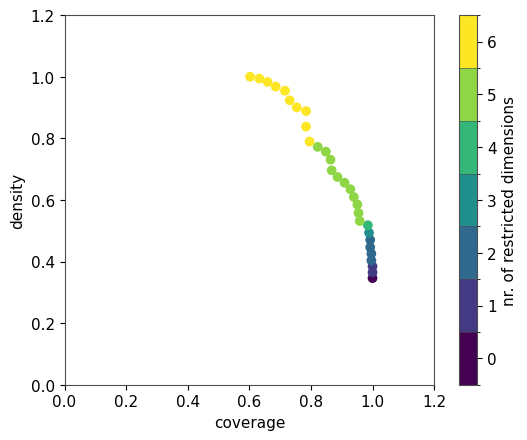

In [134]:
box_cig.show_tradeoff()
plt.show()

In [135]:
box_cig.inspect(style='data')

[(coverage      0.602273
  density       1.000000
  id           29.000000
  k           159.000000
  mass          0.208388
  mean          1.000000
  n           159.000000
  res_dim       6.000000
  Name: 29, dtype: float64,
                                 box 29                               \
                                    min            max      qp value   
  Primary Energy|Oil           3.676643     132.516287  1.000000e+00   
  Primary Energy|Gas          42.588050      92.670867  2.199700e-27   
  Primary Energy|Biomass       0.018858      41.328776           NaN   
  Primary Energy|Wind         18.901750      86.955250  2.723350e-12   
  Population                2098.103000    3131.804547           NaN   
  GDP|PPP                 123624.491197  330977.384838  1.000000e+00   
  
                                        
                              qp value  
  Primary Energy|Oil               NaN  
  Primary Energy|Gas      3.870287e-01  
  Primary Energy|Biomass  3.6

[<Figure size 640x480 with 1 Axes>]

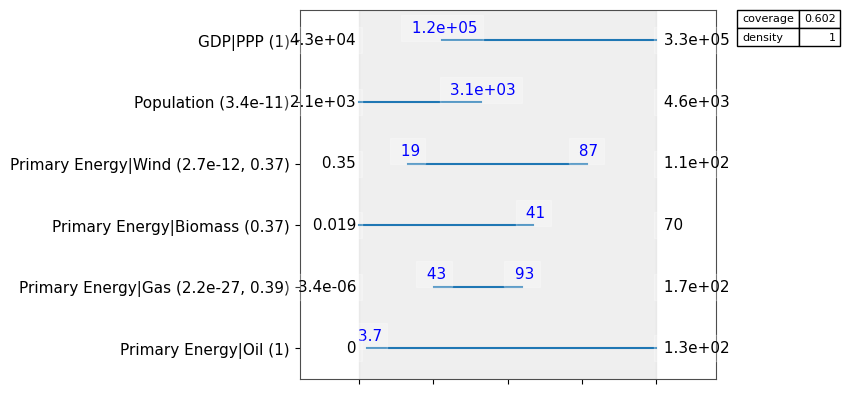

In [138]:
box_cig.inspect(style='graph')

In [139]:
box_cig.inspect_tradeoff()

alt.VConcatChart(...)

In [140]:
y_ept = (
    (data["Emissions|CO2"] <= emissions_thr) &
    (data["Final_Energy_per_capita"] < energy_thr)
).astype(int)

prim_ept = prim.Prim(x, y_ept.values)
box_ept = prim_ept.find_box()

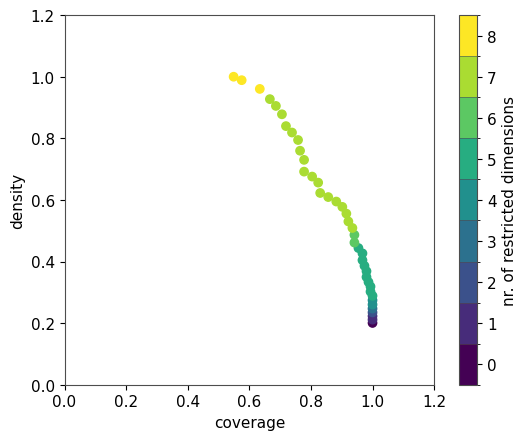

In [141]:
box_ept.show_tradeoff()
plt.show()

In [142]:
box_ept.inspect(style='data')

[(coverage     0.549020
  density      1.000000
  id          39.000000
  k           84.000000
  mass         0.110092
  mean         1.000000
  n           84.000000
  res_dim      8.000000
  Name: 39, dtype: float64,
                                box 39                               \
                                   min            max      qp value   
  Primary Energy|Coal    -3.469447e-18       5.206690           NaN   
  Primary Energy|Oil      0.000000e+00      20.290519           NaN   
  Primary Energy|Biomass  2.572122e+01      48.299752  4.006124e-15   
  Primary Energy|Nuclear  5.831976e-04      20.053854  6.946789e-02   
  Primary Energy|Solar    3.180000e-01     119.255637           NaN   
  Primary Energy|Wind     3.476000e-01      53.812205           NaN   
  Population              2.098103e+03    3413.778496           NaN   
  GDP|PPP                 4.336216e+04  229141.356900           NaN   
  
                                        
                          

[<Figure size 640x480 with 1 Axes>]

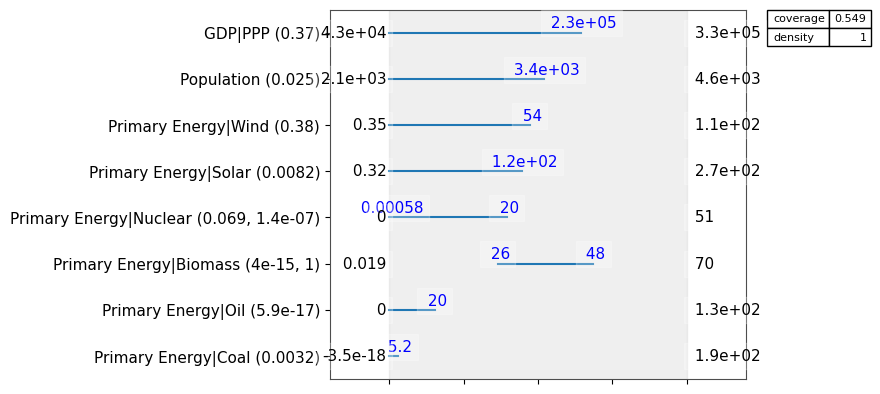

In [144]:
box_ept.inspect(style='graph')

In [145]:
box_ept.inspect_tradeoff()

alt.VConcatChart(...)

coverage      0.738562
density       0.818841
id           32.000000
k           113.000000
mass          0.180865
mean          0.818841
n           138.000000
res_dim       7.000000
Name: 32, dtype: float64

                              box 32                               \
                                 min            max      qp value   
Primary Energy|Coal    -3.469447e-18       5.206690           NaN   
Primary Energy|Oil      0.000000e+00      24.314996           NaN   
Primary Energy|Biomass  2.387093e+01      52.434991  3.907285e-07   
Primary Energy|Nuclear  0.000000e+00      20.053854           NaN   
Primary Energy|Solar    3.180000e-01     119.255637           NaN   
Primary Energy|Wind     3.476000e-01      70.963203           NaN   
GDP|PPP                 4.336216e+04  229141.356900           NaN   

                                      
                            qp value  
Primary Energy|Coal     1.024922e-01  
Primary Energy|Oil      2.984553e-09  
Primary Ener

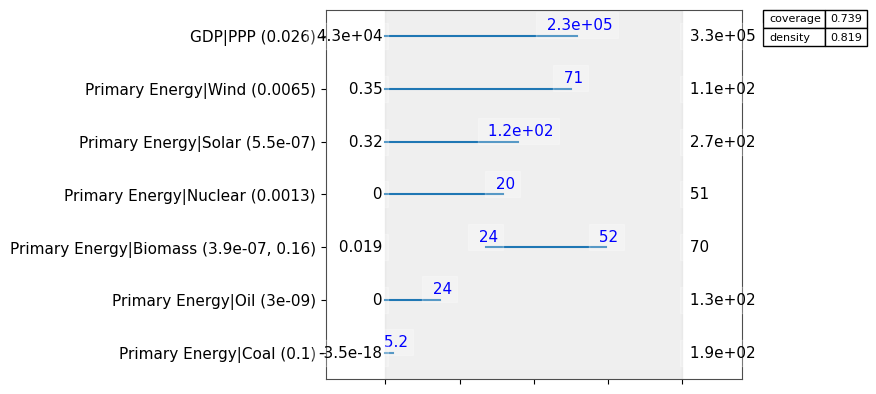

In [148]:
selected_box=32
box_ept.inspect(selected_box)
box_ept.inspect(selected_box, style="graph")
plt.show()